# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

To collect files on my local computer:
 * `cd /Users/edmond/Work/Data/DESI/DR2/loa-v1/v2/fNL/blinded`
 * `rsync -av edmondc@perlmutter-p1.nersc.gov:/pscratch/sd/e/edmondc/DR2_local_png/measurements/loa-v1/v2/fNL/blinded/ . `

In [2]:
"""
Script to fit png from the data.
"""

import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt


logger = logging.getLogger('FIT PNG')


# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [3]:
from tools import read_data, rebin_data, get_obervable_and_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

In [4]:
from clustering_statistics import setup_logging

from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

#stats_dir = Path(os.getenv('SCRATCH', '.')) / 'DR2_local_png' / 'measurements' / 'loa-v1/v2/fNL'
stats_dir =  Path('/Users/edmond/Work/Data/DESI/DR2/loa-v1/v2/fNL')

if True:
    stats_dir = stats_dir / 'blinded'
else:
    logger.error('NOT READY FOR UNBLINDED DATA YET')
    import sys
    sys.exit(3)

logger.info(f'Load data from: stats_dir: {stats_dir}')

[MacBook-Pro-de-Edmond-7.local:93805] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.MacBook-Pro-de-Edmond-7.501/jf.0/1350369280/sm_segment.MacBook-Pro-de-Edmond-7.501.507d0000.0 could be created.


[000000.00] [0/1] 03-31 11:54  FIT PNG                   INFO     Load data from: stats_dir: /Users/edmond/Work/Data/DESI/DR2/loa-v1/v2/fNL/blinded


In [5]:
# We do not link the damping term from the cross-correlation and the auto-correlation
# Because they are different effective redshifts and we do not know the a priori.

kmin, kmax = 3e-3, 0.08

use_ell2 = False
region = 'GCcomb'
tracers = ['LRG', 'QSO', 'LRGxQSO']
weight_type = ['default-fkp-oqe'] * 3
zrange = [(0.4, 1.1), (0.8, 3.5), (0.8, 1.1)]  # We neglect the correlation induces by cross mode 'below 0.8' or 'above 1.1'

kwargs = {'LRG_cross_ell0.b1': 2.15}

pks, windows, covs = {}, {}, {}
observables, likelihoods = {}, {}

for tracer, weight_type, zrange in zip(tracers, weight_type, zrange):

    pk, window, cov = read_data(stats_dir=stats_dir, tracer=tracer, zrange=zrange, weight_type=weight_type, region=region)
    pk, window, cov = rebin_data(pk, window, cov, tracer=tracer, kmin=kmin, kmax=kmax, use_ell2=use_ell2)
    observable, likelihood = get_obervable_and_likelihood(pk, window, cov, tracer, engine='camb', **kwargs)

    run_profiler(likelihood)

    pks[tracer], windows[tracer], covs[tracer] = pk, window, cov
    observables[tracer], likelihoods[tracer] = observable, likelihood

[000006.69] [0/1] 03-31 11:54  PNG fitting tools         INFO     After rebinning and k range selection: 47 and Not used data points.
[000006.92] [0/1] 03-31 11:54  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000008.20] [0/1] 03-31 11:54  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000008.36] [0/1] 03-31 11:54  MinuitProfiler            INFO     Successfully jit input likelihood.
[000010.70] [0/1] 03-31 11:54  PNG fitting tools         INFO     
+-------------------------------------+--------+---------+-------+
| chi2 / (47 - 4) = 50.08 / 43 = 1.16 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   -2    |  13   |
|            LRG_ell0.sn0             |  True  |  0.15   | 0.55  |
|             LRG_ell0.b1             |  True  |  2.12   | 0.12  |
|           LRG_ell0.sigmas         

In [6]:
print('Nbr points in ell=0:', pk.get(0).value().shape[0])
#print('Nbr points in ell=2:', pk.get(2).value().shape[0])

Nbr points in ell=0: 47


/Users/edmond/Work/desi-clustering/local_png/tools.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend()


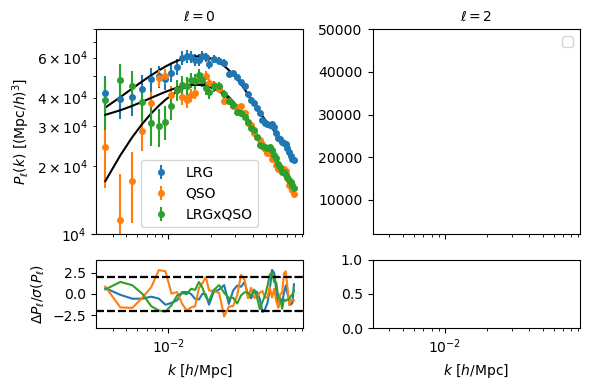

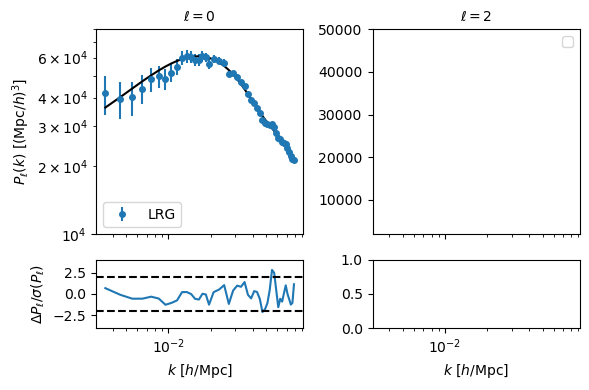

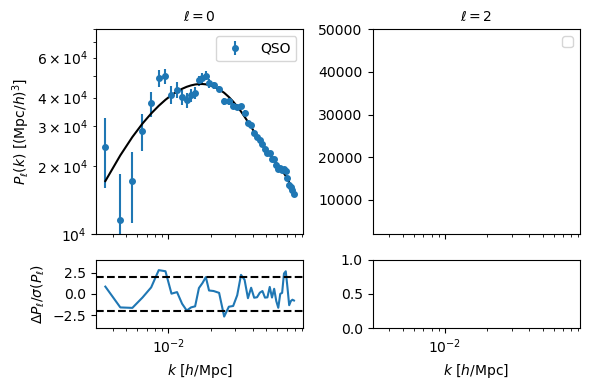

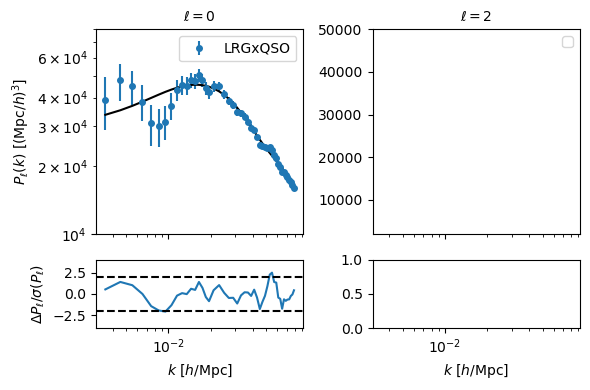

In [7]:
plot_observables(observables)

for tracer in observables.keys():
    plot_observables({tracer: observables[tracer]})

In [8]:
samplers = {}

for tracer in likelihoods.keys():
    logger.info(f'Run MCMC for {tracer=}:')
    samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

[000017.94] [0/1] 03-31 11:54  FIT PNG                   INFO     Run MCMC for tracer='LRG':
[000017.95] [0/1] 03-31 11:54  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[None]
[000018.64] [0/1] 03-31 11:54  EmceeSampler              INFO     Successfully vmap input likelihood.
[000018.76] [0/1] 03-31 11:54  EmceeSampler              INFO     Successfully jit input likelihood.
[000033.12] [0/1] 03-31 11:55  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000045.90] [0/1] 03-31 11:55  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000058.01] [0/1] 03-31 11:55  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000070.06] [0/1] 03-31 11:55  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000070.06] [0/1] 03-31 11:55  FIT PNG                   INFO     Run MCMC for tracer='QSO':
[000070.06] [0/1] 03-31 11:55  EmceeSampler              INFO     Varied

Nbr points for tracer='LRG': 14000
Nbr points for tracer='QSO': 14000
Nbr points for tracer='LRGxQSO': 14000
Removed no burn in
Removed no burn in
Removed no burn in


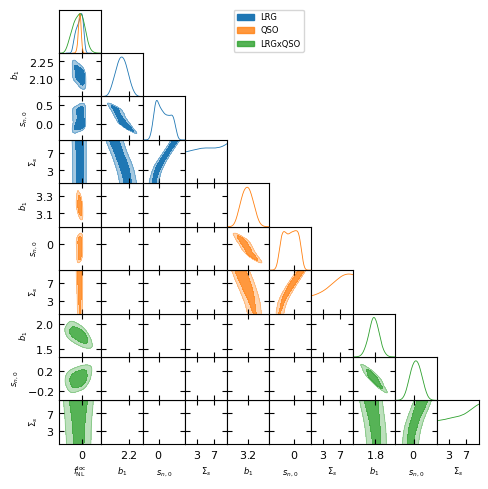

Removed no burn in
Removed no burn in
Removed no burn in


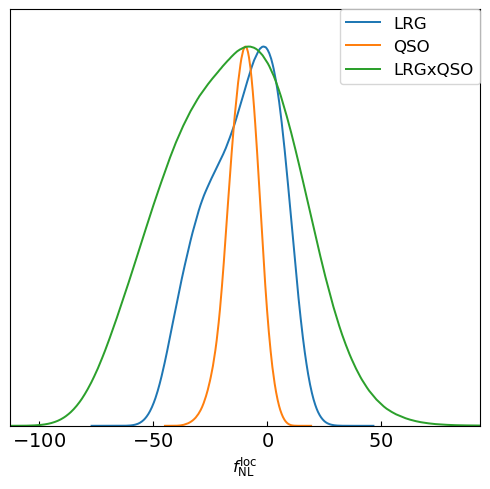

In [9]:
from desilike.samples import Chain

burnin, thin = 0.3, 10

chains = {}

#chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

for tracer in samplers.keys():
     chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
     print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas', 'QSO_cross_ell0.b1', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas']
xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']

plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(chains.keys()), xlabels=xlabels, 
              filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
              filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

In [10]:
## PLUS J4IA PAS UN BEAU PK ALORS QUE AVANT JEN AVAIS UN ! KEPASA ??   --> COMPARER AVEC DR2 FKP 

In [11]:
# Build the total analytical covariance :
# Use .match function to apply the same selection for each part of the covariance matrix in cov['LRGxQSO']

from lsstypes import ObservableTree

_tracer_split = [('LRG', 'LRG'), ('LRG', 'QSO'), ('QSO', 'QSO')]
_observables = ['spectrum2', 'spectrum2', 'spectrum2']
pk_join = [pks['LRG'], pks['LRGxQSO'], pks['QSO']]

super_observable = ObservableTree(pk_join, observables=_observables, tracers=_tracer_split)
super_cov = covs['LRGxQSO'].copy()

# Smart enough that it directly apply the same cut and rebin that each pk:
super_cov = super_cov.at.observable.match(super_observable).value()

print(super_cov.shape)
print(np.sum([pk.size for pk in pk_join]))

#plt.plot(np.diag(super_cov))

# # Update with the covariance of the auto-correlations. We neglect the cross-mode. 
# super_cov[:pks['LRG'].size, :pks['LRG'].size] = covs['LRG'].value()
# super_cov[-pks['QSO'].size:, -pks['QSO'].size:] = covs['QSO'].value()

#plt.plot(np.diag(super_cov), ls='--')

(141, 141)
141


In [12]:
# how will we do with the mocks? (I think nothing, it will straight forwards, like providing the mocks for each obseravble and desilike will take the standard deviation ect... ) --> no PROBLEME

flatten_observables = [observable for tracer in tracers for observable in observables[tracer]]  # inefficient for large list, here ok ... 

from desilike.likelihoods import ObservablesGaussianLikelihood
total_likelihood = ObservablesGaussianLikelihood(observables=flatten_observables, covariance=super_cov, scale_covariance=1)

for tracer in tracers: 
    tt = tuple(tracer.split('x')) 
    if len(tt) == 1: tt *= 2

    # if len(pks[tracer].ells) > 1:
    #     from clustering_statistics import tools
    #     # let ell2.b1 be derived by ell0.b1: 
    #     if tt[0] != tt[1]: logger.warning(f'We use the bias evolution of {tt[0]} (that should be ok -> be careful when using auto + cross together')

    #     zeff = [windows[tracer].observable.get(ell).attrs['zeff'] for ell in [0,2]]
    #     alpha, beta = tools.bias(1, tracer=tt[0], return_params=True)  # b(z) = alpha * (1 + z)**2 + beta
    #     factor = (alpha * (1 + zeff[1])**2 + beta) / (alpha * (1 + zeff[0])**2 + beta)
    #     total_likelihood.all_params[f'{tracer}_ell2.b1'].update(derived='{' + f'{tracer}_ell0.b1' + '}' + f' * {factor}')

logger.info(total_likelihood.varied_params)

total_likelihood()

[000172.43] [0/1] 03-31 11:57  FIT PNG                   INFO     ParameterCollection(['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'LRG_cross_ell0.b1', 'QSO_cross_ell0.b1', 'LRG_cross_ell0.sigmas', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'])


Array(-1362.58743902, dtype=float64)

[000172.52] [0/1] 03-31 11:57  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'LRG_cross_ell0.b1', 'QSO_cross_ell0.b1', 'LRG_cross_ell0.sigmas', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000172.83] [0/1] 03-31 11:57  MinuitProfiler            INFO     Successfully jit input likelihood.
[000195.57] [0/1] 03-31 11:57  PNG fitting tools         INFO     
+------------------------------------------------------+--------+--------------+---------+
| chi2 / (141 - 12) = -113768622.89 / 129 = -881927.31 | varied |   bestfit    |  error  |
+------------------------------------------------------+--------+--------------+---------+
|                       fnl_loc                        |  True  | 300.00000000 | 8.2e-7  |
|          LRG_cross_ell0xQSO_cross_ell0.sn0           |  True  |   -20.220    |  0.027  |
|                  LRG_cross_ell0.b1              

/Users/edmond/Work/desi-clustering/local_png/tools.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend()


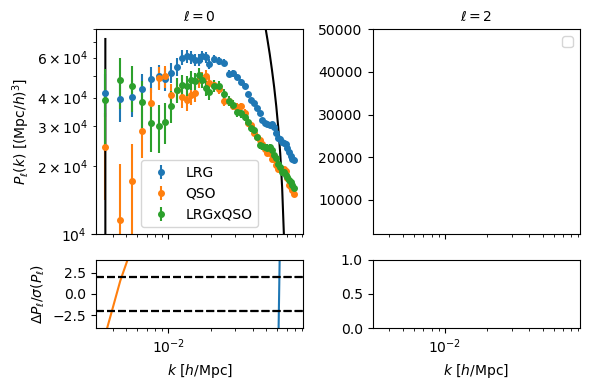

In [13]:
run_profiler(total_likelihood)
plot_observables(observables)

In [ ]:
## IMPORTANT COMMENT FAIRE POUR HARTLPA/PERCIVAL -> COMMENT DESILIKE DONNE LES VAEURS DE CHI2 (qui ne doit pas avoir percival)
# 
https://github.com/cosmodesi/desi-clustering/blob/7b1f38fcacbfa4ef815f56c345b5072f2a3a7d26/full_shape/tools.py#L301